## 0. Install & Import Dependencies

In [1]:
!rm -rf /kaggle/working/patches

In [2]:
!pip install -q segmentation-models-pytorch albumentations tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
import random
import shutil
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics / Analysis
from sklearn.metrics import jaccard_score, f1_score, accuracy_score
from scipy import ndimage
from skimage import measure, morphology

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')

Using device: cuda
CUDA available: True


---
## Stage 1 – Preprocessing & Tiling

In [4]:
# ─────────────────────────────────────────────
# CONFIGURATION – adjust paths for your setup
# ─────────────────────────────────────────────
# If using Kaggle Dataset, images are at /kaggle/input/inria-aerial/
# Adjust the paths below accordingly.

INRIA_TRAIN_IMG = Path('/kaggle/input/datasets/sagar100rathod/inria-aerial-image-labeling-dataset/AerialImageDataset/train/images')
INRIA_TRAIN_GT  = Path('/kaggle/input/datasets/sagar100rathod/inria-aerial-image-labeling-dataset/AerialImageDataset/train/gt')

OUTPUT_DIR  = Path('/kaggle/working/patches')
TRAIN_DIR   = OUTPUT_DIR / 'train'
VAL_DIR     = OUTPUT_DIR / 'val'
TEST_DIR    = OUTPUT_DIR / 'test'

PATCH_SIZE   = 512   # px
STRIDE       = 512   # no overlap; set to 256 for overlap
MIN_BUILDING = 0.02  # drop patches with < 2% building pixels
VAL_RATIO    = 0.10
TEST_RATIO   = 0.10

for d in [TRAIN_DIR/'images', TRAIN_DIR/'masks',
          VAL_DIR/'images',   VAL_DIR/'masks',
          TEST_DIR/'images',  TEST_DIR/'masks']:
    d.mkdir(parents=True, exist_ok=True)

print('Output directories created.')

Output directories created.


In [5]:
def tile_image_and_mask(img_path, gt_path, patch_size=512, stride=512, min_building=0.02):
    """
    Slice one full-resolution image (5000×5000) and its GT mask
    into patches of size `patch_size` × `patch_size`.
    Returns list of (img_patch, mask_patch) numpy arrays.
    Drops nearly empty patches (< min_building fraction).
    """
    img  = cv2.imread(str(img_path))   # BGR
    mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        return []

    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Binarize GT: white pixels (≥128) = building
    _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

    H, W = img.shape[:2]
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            img_patch  = img [y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            building_ratio = mask_patch.mean()
            if building_ratio >= min_building:
                patches.append((img_patch, mask_patch))

    return patches


def build_patch_dataset(img_dir, gt_dir, patch_size=512, stride=512,
                        min_building=0.02, val_ratio=0.10, test_ratio=0.10,
                        train_dir=None, val_dir=None, test_dir=None):
    """
    Iterate over all image/mask pairs, tile them, and split into
    train / val / test sets saved to disk.
    """
    img_files = sorted(img_dir.glob('*.tif')) + sorted(img_dir.glob('*.png'))
    print(f'Found {len(img_files)} source images.')

    all_patches = []
    for img_path in tqdm(img_files, desc='Tiling images'):
        stem     = img_path.stem
        gt_path  = gt_dir / img_path.name
        if not gt_path.exists():
            gt_path = (gt_dir / stem).with_suffix('.tif')
        if not gt_path.exists():
            continue
        patches = tile_image_and_mask(img_path, gt_path, patch_size, stride, min_building)
        for i, (img_p, msk_p) in enumerate(patches):
            all_patches.append((f'{stem}_{i:04d}', img_p, msk_p))

    random.shuffle(all_patches)
    n      = len(all_patches)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)

    splits = {
        'test' : (all_patches[:n_test],              test_dir),
        'val'  : (all_patches[n_test:n_test+n_val],  val_dir),
        'train': (all_patches[n_test+n_val:],        train_dir),
    }

    for split_name, (items, out_dir) in splits.items():
        for name, img_p, msk_p in tqdm(items, desc=f'Saving {split_name}'):
            cv2.imwrite(str(out_dir/'images'/f'{name}.png'),
                        cv2.cvtColor(img_p, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str(out_dir/'masks' /f'{name}.png'),
                        (msk_p * 255).astype(np.uint8))

    print(f'\nDataset split: train={len(splits["train"][0])},'
          f' val={len(splits["val"][0])}, test={len(splits["test"][0])}')
    return splits


# Run tiling (comment out if patches already exist)
if INRIA_TRAIN_IMG.exists():
    build_patch_dataset(
        img_dir=INRIA_TRAIN_IMG, gt_dir=INRIA_TRAIN_GT,
        patch_size=PATCH_SIZE, stride=STRIDE,
        min_building=MIN_BUILDING,
        val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
        train_dir=TRAIN_DIR, val_dir=VAL_DIR, test_dir=TEST_DIR,
    )
else:
    print('Dataset path not found – skipping tiling (demo mode).')

Found 180 source images.


Tiling images:   0%|          | 0/180 [00:00<?, ?it/s][ WARN:0@18.707] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@18.707] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@18.707] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@18.707] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@20.230] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@20.230] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@20.230] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@20.230] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirecto


Dataset split: train=8329, val=1041, test=1041


---
## Stage 2a – Model 1: K-Means Baseline

In [6]:
def kmeans_building_segment(img_rgb, n_clusters=4, building_cluster='auto'):
    """
    Segment buildings using K-Means on HSV + RGB features.

    Parameters
    ----------
    img_rgb       : HxWx3 numpy array (uint8, RGB)
    n_clusters    : number of K-Means clusters
    building_cluster : 'auto' selects the cluster with brightest V channel
                       (rooftops tend to be bright in aerial imagery)

    Returns
    -------
    binary_mask   : HxW numpy array {0, 1}
    labels_2d     : HxW cluster-label image (for visualization)
    """
    H, W = img_rgb.shape[:2]

    # --- Feature space: concatenate RGB + HSV ---
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32) / 255.0
    img_f   = img_rgb.astype(np.float32) / 255.0

    features = np.concatenate([
        img_f.reshape(-1, 3),
        img_hsv.reshape(-1, 3)
    ], axis=1)  # shape: (H*W, 6)

    # --- K-Means clustering ---
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(
        features.astype(np.float32),
        n_clusters, None, criteria,
        attempts=5,
        flags=cv2.KMEANS_PP_CENTERS
    )
    labels_2d = labels.reshape(H, W)

    # --- Select building cluster ---
    if building_cluster == 'auto':
        # Heuristic: rooftops are generally bright → high V channel in HSV
        # centers columns: R G B H S V (indices 3,4,5 are HSV)
        v_channel = centers[:, 5]     # V component of cluster centers
        building_cluster = int(np.argmax(v_channel))

    binary_mask = (labels_2d == building_cluster).astype(np.uint8)
    return binary_mask, labels_2d


def run_kmeans_on_folder(img_dir, save_dir, n_clusters=4, n_samples=None):
    """
    Run K-Means segmentation on all images in `img_dir`.
    Saves binary prediction masks to `save_dir`.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    img_files = sorted(Path(img_dir).glob('*.png'))
    if n_samples:
        img_files = img_files[:n_samples]

    for img_path in tqdm(img_files, desc='K-Means inference'):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        pred, _ = kmeans_building_segment(img, n_clusters=n_clusters)

        # Morphological cleanup (Stage 3 integrated for baseline)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        pred = cv2.morphologyEx(pred, cv2.MORPH_CLOSE, kernel, iterations=2)
        pred = cv2.morphologyEx(pred, cv2.MORPH_OPEN,  kernel, iterations=1)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), (pred * 255).astype(np.uint8))

    print(f'K-Means predictions saved to {save_dir}')


# Run on test set
KMEANS_PRED_DIR = Path('/kaggle/working/kmeans_preds')
if TEST_DIR.exists():
    run_kmeans_on_folder(TEST_DIR/'images', KMEANS_PRED_DIR, n_clusters=4)

K-Means inference: 100%|██████████| 1041/1041 [02:30<00:00,  6.91it/s]

K-Means predictions saved to /kaggle/working/kmeans_preds


## Stage 2b – Model 2: U-Net with ResNet34 Encoder

In [7]:
# ─── PyTorch Dataset ───────────────────────────────────────────────────────────

class BuildingDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_paths  = sorted(Path(img_dir).glob('*.png'))
        self.mask_dir   = Path(mask_dir)
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path  = self.img_paths[idx]
        mask_path = self.mask_dir / img_path.name

        img  = cv2.cvtColor(cv2.imread(str(img_path)),  cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)   # binary {0, 1}

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        return img, mask.long()


# ─── Augmentations ────────────────────────────────────────────────────────────

MEAN = [0.485, 0.456, 0.406]   # ImageNet stats
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.GaussNoise(p=0.1),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('Dataset classes and transforms defined.')

Dataset classes and transforms defined.


In [8]:
# ─── Loss Functions ────────────────────────────────────────────────────────────

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits.squeeze(1))          # (B, H, W)
        targets = targets.float()
        inter   = (probs * targets).sum(dim=(1, 2))
        union   = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))
        dice    = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """BCE + Dice loss (equal weights)."""
    def __init__(self):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits.squeeze(1), targets.float()) + self.dice(logits, targets)


print('Loss functions defined.')

Loss functions defined.


In [9]:
# ─── Training & Validation Loops ───────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)          # (B, 1, H, W)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, dice_scores = 0, []
    for imgs, masks in tqdm(loader, desc='Val  ', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        total_loss += loss.item()

        preds = (torch.sigmoid(logits.squeeze(1)) > 0.5).cpu().numpy()
        trues = masks.cpu().numpy()
        for p, t in zip(preds, trues):
            inter = (p & t.astype(bool)).sum()
            union = p.sum() + t.sum()
            dice_scores.append((2 * inter + 1) / (union + 1))

    return total_loss / len(loader), np.mean(dice_scores)


def train_unet(
    train_dir, val_dir,
    num_epochs=30,
    batch_size=8,
    lr=1e-4,
    checkpoint_path='/kaggle/working/unet_best.pth'
):
    # ── Datasets & Loaders
    train_ds = BuildingDataset(train_dir/'images', train_dir/'masks', train_transform)
    val_ds   = BuildingDataset(val_dir  /'images', val_dir  /'masks', val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f'Train patches: {len(train_ds)} | Val patches: {len(val_ds)}')

    # ── Model: U-Net with pretrained ResNet34 encoder
    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
    ).to(DEVICE)

    criterion = CombinedLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_dice    = 0
    history      = {'train_loss': [], 'val_loss': [], 'val_dice': []}

    for epoch in range(1, num_epochs + 1):
        tr_loss            = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl_loss, vl_dice   = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_dice'].append(vl_dice)

        if vl_dice > best_dice:
            best_dice = vl_dice
            torch.save(model.state_dict(), checkpoint_path)
            tag = ' ← best'
        else:
            tag = ''

        print(f'Epoch {epoch:03d}/{num_epochs} | '
              f'Train Loss: {tr_loss:.4f} | '
              f'Val Loss: {vl_loss:.4f} | '
              f'Val Dice: {vl_dice:.4f}{tag}')

    print(f'\nBest Val Dice: {best_dice:.4f} — saved to {checkpoint_path}')
    return model, history


# Run training
if TRAIN_DIR.exists():
    model, history = train_unet(
        TRAIN_DIR, VAL_DIR,
        num_epochs=30,
        batch_size=8,
        lr=1e-4,
    )
else:
    print('Training data not found – skipping training (demo mode).')

Train patches: 8329 | Val patches: 1041


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 001/30 | Train Loss: 0.6675 | Val Loss: 0.4270 | Val Dice: 0.8220 ← best


Epoch 002/30 | Train Loss: 0.4615 | Val Loss: 0.3888 | Val Dice: 0.8316 ← best


...

Epoch 026/30 | Train Loss: 0.2897 | Val Loss: 0.3041 | Val Dice: 0.8678


Epoch 027/30 | Train Loss: 0.2870 | Val Loss: 0.3048 | Val Dice: 0.8689 ← best


Epoch 028/30 | Train Loss: 0.2879 | Val Loss: 0.3042 | Val Dice: 0.8685


Epoch 029/30 | Train Loss: 0.2866 | Val Loss: 0.3042 | Val Dice: 0.8682


Epoch 030/30 | Train Loss: 0.2859 | Val Loss: 0.3040 | Val Dice: 0.8685

Best Val Dice: 0.8689 — saved to /kaggle/working/unet_best.pth


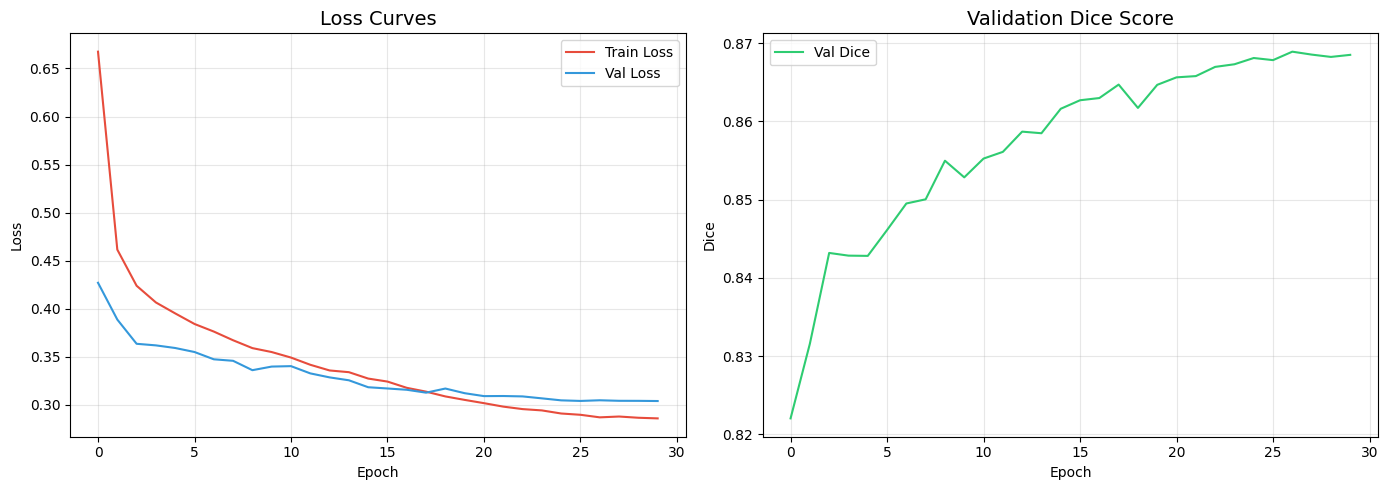

In [10]:
# ─── Plot Training Curves ──────────────────────────────────────────────────────

if 'history' in dir():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='#e74c3c')
    ax1.plot(history['val_loss'],   label='Val Loss',   color='#3498db')
    ax1.set_title('Loss Curves', fontsize=14)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history['val_dice'], label='Val Dice', color='#2ecc71')
    ax2.set_title('Validation Dice Score', fontsize=14)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Stage 3 – Morphological Post-processing

In [11]:
def morphological_cleanup(binary_mask, close_ksize=9, open_ksize=5):
    """
    Apply morphological operations to clean up a binary prediction mask.

    Steps:
        1. Closing  – fill holes inside rooftops
        2. Opening  – remove small noise / isolated blobs
        3. Remove small connected components (< min_area pixels)

    Parameters
    ----------
    binary_mask : HxW numpy array {0, 1} uint8
    close_ksize : kernel size for closing (larger → fills bigger holes)
    open_ksize  : kernel size for opening (larger → removes bigger noise)

    Returns
    -------
    cleaned : HxW numpy array {0, 1} uint8
    """
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ksize,  open_ksize))

    # 1. Fill holes inside buildings
    closed  = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, k_close, iterations=2)
    # 2. Remove small noise blobs
    opened  = cv2.morphologyEx(closed,      cv2.MORPH_OPEN,  k_open,  iterations=1)

    # 3. Remove connected components smaller than a threshold
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
    min_area = 200   # pixels; tune as needed
    cleaned  = np.zeros_like(opened)
    for lbl in range(1, n_labels):   # label 0 = background
        area = stats[lbl, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == lbl] = 1

    return cleaned


def postprocess_predictions_folder(pred_dir, cleaned_dir):
    """
    Run cleanup on all prediction masks in `pred_dir`;
    save results to `cleaned_dir`.
    """
    cleaned_dir = Path(cleaned_dir)
    cleaned_dir.mkdir(parents=True, exist_ok=True)

    for pred_path in tqdm(sorted(Path(pred_dir).glob('*.png')), desc='Postprocess'):
        pred = cv2.imread(str(pred_path), cv2.IMREAD_GRAYSCALE)
        pred_bin = (pred > 127).astype(np.uint8)
        cleaned  = morphological_cleanup(pred_bin)
        cv2.imwrite(str(cleaned_dir / pred_path.name),
                    (cleaned * 255).astype(np.uint8))

    print(f'Cleaned masks saved to {cleaned_dir}')


# Apply to K-Means predictions
KMEANS_CLEAN_DIR = Path('/kaggle/working/kmeans_preds_clean')
if KMEANS_PRED_DIR.exists():
    postprocess_predictions_folder(KMEANS_PRED_DIR, KMEANS_CLEAN_DIR)

Postprocess: 100%|██████████| 1041/1041 [00:07<00:00, 147.89it/s]

Cleaned masks saved to /kaggle/working/kmeans_preds_clean


In [12]:
# ─── U-Net inference on test set ───────────────────────────────────────────────

@torch.no_grad()
def unet_inference_folder(
    model, img_dir, save_dir,
    threshold=0.5,
    apply_cleanup=True
):
    """
    Run trained U-Net on every image in `img_dir`;
    save binary prediction masks to `save_dir`.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    model.eval()

    for img_path in tqdm(sorted(Path(img_dir).glob('*.png')), desc='U-Net inference'):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

        aug   = val_transform(image=img)
        inp   = aug['image'].unsqueeze(0).to(DEVICE)
        logit = model(inp)
        prob  = torch.sigmoid(logit.squeeze()).cpu().numpy()
        pred  = (prob > threshold).astype(np.uint8)

        if apply_cleanup:
            pred = morphological_cleanup(pred)

        cv2.imwrite(str(save_dir / img_path.name),
                    (pred * 255).astype(np.uint8))

    print(f'U-Net predictions saved to {save_dir}')


UNET_PRED_DIR = Path('/kaggle/working/unet_preds_clean')
if 'model' in dir() and TEST_DIR.exists():
    # Load best checkpoint
    model.load_state_dict(torch.load('/kaggle/working/unet_best.pth', map_location=DEVICE))
    unet_inference_folder(model, TEST_DIR/'images', UNET_PRED_DIR)

U-Net inference: 100%|██████████| 1041/1041 [00:32<00:00, 31.76it/s]

U-Net predictions saved to /kaggle/working/unet_preds_clean


---
## Stage 4 – Evaluation & Connected-Region Analysis

In [13]:
# ─── Segmentation Metrics ─────────────────────────────────────────────────────

def compute_metrics(pred_dir, gt_dir, n_samples=None):
    """
    Compute pixel-level Accuracy, IoU (Jaccard), and Dice (F1)
    by comparing predicted masks to ground-truth masks.

    Returns
    -------
    dict with mean accuracy, IoU, Dice, and per-image arrays.
    """
    pred_files = sorted(Path(pred_dir).glob('*.png'))
    if n_samples:
        pred_files = pred_files[:n_samples]

    accs, ious, dices = [], [], []

    for pred_path in tqdm(pred_files, desc='Evaluating'):
        gt_path = Path(gt_dir) / pred_path.name
        if not gt_path.exists():
            continue

        pred = (cv2.imread(str(pred_path), cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8).ravel()
        gt   = (cv2.imread(str(gt_path),   cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8).ravel()

        acc  = accuracy_score(gt, pred)
        iou  = jaccard_score (gt, pred, zero_division=0)
        dice = f1_score      (gt, pred, zero_division=0)

        accs.append(acc); ious.append(iou); dices.append(dice)

    results = {
        'mean_accuracy': np.mean(accs),
        'mean_iou'     : np.mean(ious),
        'mean_dice'    : np.mean(dices),
        'per_image_iou': ious,
        'per_image_dice': dices,
    }
    return results


if TEST_DIR.exists():
    gt_dir = TEST_DIR / 'masks'

    print('\n=== K-Means (+ Morphology) ===')
    if KMEANS_CLEAN_DIR.exists():
        km_res = compute_metrics(KMEANS_CLEAN_DIR, gt_dir)
        for k, v in km_res.items():
            if isinstance(v, float):
                print(f'  {k}: {v:.4f}')

    print('\n=== U-Net (+ Morphology) ===')
    if UNET_PRED_DIR.exists():
        un_res = compute_metrics(UNET_PRED_DIR, gt_dir)
        for k, v in un_res.items():
            if isinstance(v, float):
                print(f'  {k}: {v:.4f}')


=== K-Means (+ Morphology) ===


Evaluating: 100%|██████████| 1041/1041 [00:57<00:00, 18.04it/s]


  mean_accuracy: 0.7265
  mean_iou: 0.2647
  mean_dice: 0.3971

=== U-Net (+ Morphology) ===


Evaluating: 100%|██████████| 1041/1041 [00:57<00:00, 18.21it/s]

  mean_accuracy: 0.9464
  mean_iou: 0.7743
  mean_dice: 0.8669


In [14]:
# ─── Comparison Table ─────────────────────────────────────────────────────────

import pandas as pd

if TEST_DIR.exists() and 'km_res' in dir() and 'un_res' in dir():
    comparison = pd.DataFrame({
        'Method'  : ['K-Means + Morphology', 'U-Net (ResNet34) + Morphology'],
        'Accuracy': [km_res['mean_accuracy'], un_res['mean_accuracy']],
        'IoU'     : [km_res['mean_iou'],      un_res['mean_iou']],
        'Dice'    : [km_res['mean_dice'],     un_res['mean_dice']],
    })
    print('\n' + comparison.to_string(index=False))
    comparison.to_csv('/kaggle/working/metrics_comparison.csv', index=False)


                       Method  Accuracy      IoU     Dice
         K-Means + Morphology  0.726452 0.264716 0.397053
U-Net (ResNet34) + Morphology  0.946437 0.774334 0.866905


In [15]:
# ─── Connected-Region Analysis ─────────────────────────────────────────────────

def analyze_buildings(pred_mask_uint8, pixel_area_m2=None):
    """
    Identify individual building instances via connected-component labeling
    and compute spatial statistics.

    Parameters
    ----------
    pred_mask_uint8 : HxW numpy {0, 255}
    pixel_area_m2   : optional — area of one pixel in m² for real-world stats
                      (Inria dataset: 0.3 m/px → 0.09 m²/px)

    Returns
    -------
    stats_df  : pandas DataFrame with per-building stats
    labeled   : HxW labeled image (each building has a unique integer)
    """
    binary = (pred_mask_uint8 > 127).astype(np.uint8)

    # Label connected components
    labeled   = measure.label(binary, connectivity=2)
    props     = measure.regionprops(labeled)

    records = []
    for prop in props:
        row = {
            'building_id'  : prop.label,
            'area_px'      : prop.area,
            'bbox_height'  : prop.bbox[2] - prop.bbox[0],
            'bbox_width'   : prop.bbox[3] - prop.bbox[1],
            'centroid_y'   : prop.centroid[0],
            'centroid_x'   : prop.centroid[1],
            'perimeter'    : prop.perimeter,
            'eccentricity' : prop.eccentricity,
            'solidity'     : prop.solidity,
        }
        if pixel_area_m2:
            row['area_m2'] = prop.area * pixel_area_m2
        records.append(row)

    stats_df = pd.DataFrame(records)
    img_H, img_W = binary.shape
    total_area_px = binary.sum()

    print(f'Number of buildings detected : {len(props)}')
    print(f'Total building area          : {total_area_px} px '
          f'({total_area_px / (img_H * img_W) * 100:.1f}% of image)')
    if pixel_area_m2:
        print(f'Total building area          : {total_area_px * pixel_area_m2:.1f} m²')
    if len(stats_df):
        print(f'Avg building area            : {stats_df["area_px"].mean():.1f} px')

    return stats_df, labeled


# Demo on one test prediction
if UNET_PRED_DIR.exists():
    sample_pred = sorted(UNET_PRED_DIR.glob('*.png'))[0]
    sample_mask = cv2.imread(str(sample_pred), cv2.IMREAD_GRAYSCALE)
    print(f'\nConnected-region analysis for: {sample_pred.name}')
    df_buildings, labeled_img = analyze_buildings(sample_mask, pixel_area_m2=0.09)
    if len(df_buildings):
        display(df_buildings.head(10))


Connected-region analysis for: austin10_0002.png
Number of buildings detected : 3
Total building area          : 3787 px (1.4% of image)
Total building area          : 340.8 m²
Avg building area            : 1262.3 px


,building_id,area_px,bbox_height,bbox_width,centroid_y,centroid_x,perimeter,eccentricity,solidity,area_m2
0,1,347.0,21,23,89.844380,194.118156,69.355339,0.562559,0.953297,31.23
1,2,629.0,23,36,415.146264,39.585056,99.355339,0.811039,0.957382,56.61
2,3,2811.0,63,51,481.722519,40.878335,205.497475,0.601405,0.974012,252.99


---
## Stage 5 – Visualization & Reporting

In [16]:
def overlay_mask_on_image(img_rgb, mask_bin, color=(255, 0, 0), alpha=0.45):
    """
    Blend a binary mask as a semi-transparent colored overlay onto `img_rgb`.

    Parameters
    ----------
    img_rgb  : HxWx3 uint8
    mask_bin : HxW   {0, 1} uint8
    color    : RGB tuple for building regions
    alpha    : opacity of the overlay

    Returns
    -------
    blended  : HxWx3 uint8
    """
    overlay = img_rgb.copy().astype(np.float32)
    for c, col_val in enumerate(color):
        overlay[:, :, c][mask_bin == 1] = (
            overlay[:, :, c][mask_bin == 1] * (1 - alpha) + col_val * alpha
        )
    return overlay.clip(0, 255).astype(np.uint8)


def side_by_side_comparison(img_rgb, gt_mask, km_mask, unet_mask, title=''):
    """
    4-panel comparison: Original | Ground Truth | K-Means | U-Net
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    panels = [
        (img_rgb,                           'Original Image'),
        (overlay_mask_on_image(img_rgb, gt_mask,    color=(0,   200, 0)),   'Ground Truth'),
        (overlay_mask_on_image(img_rgb, km_mask,    color=(255, 100, 0)),   'K-Means'),
        (overlay_mask_on_image(img_rgb, unet_mask,  color=(0,   100, 255)), 'U-Net'),
    ]

    for ax, (panel, panel_title) in zip(axes, panels):
        ax.imshow(panel)
        ax.set_title(panel_title, fontsize=12)
        ax.axis('off')

    # Legend
    legend_elements = [
        mpatches.Patch(color=(0/255, 200/255, 0/255),   label='Ground Truth'),
        mpatches.Patch(color=(255/255, 100/255, 0/255), label='K-Means'),
        mpatches.Patch(color=(0/255, 100/255, 255/255), label='U-Net'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, bbox_to_anchor=(0.5, -0.06), fontsize=11)

    plt.tight_layout()
    return fig


print('Visualization functions defined.')

Visualization functions defined.


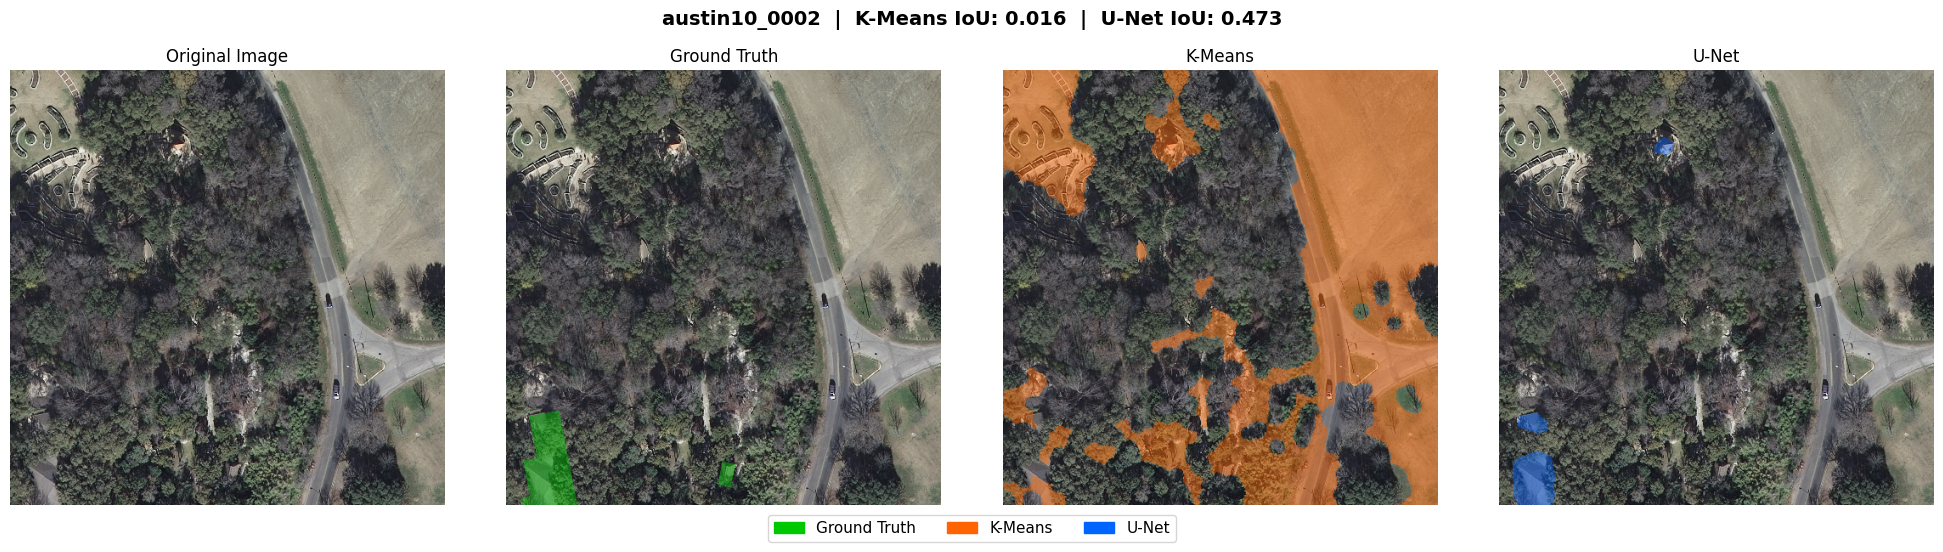

Saved: /kaggle/working/visualizations/comparison_01_austin10_0002.png


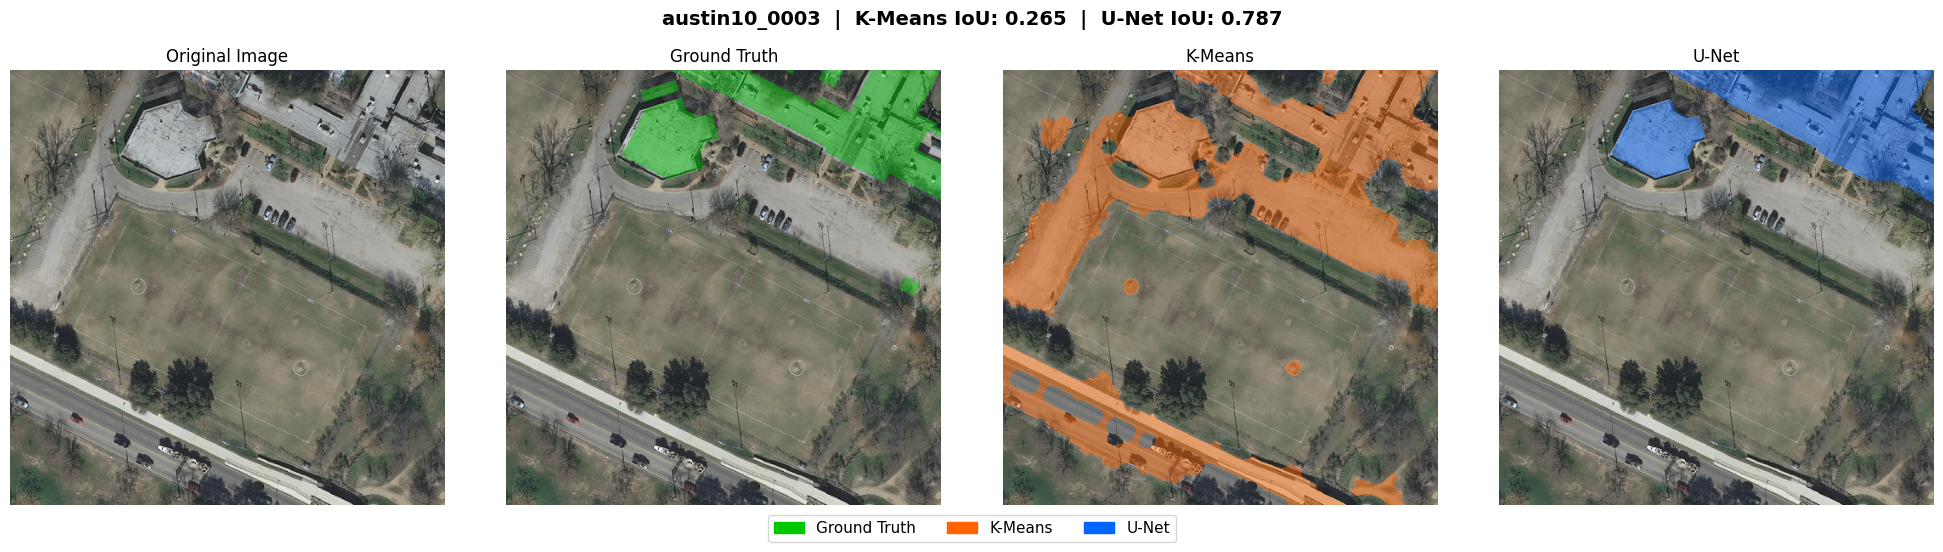

Saved: /kaggle/working/visualizations/comparison_02_austin10_0003.png


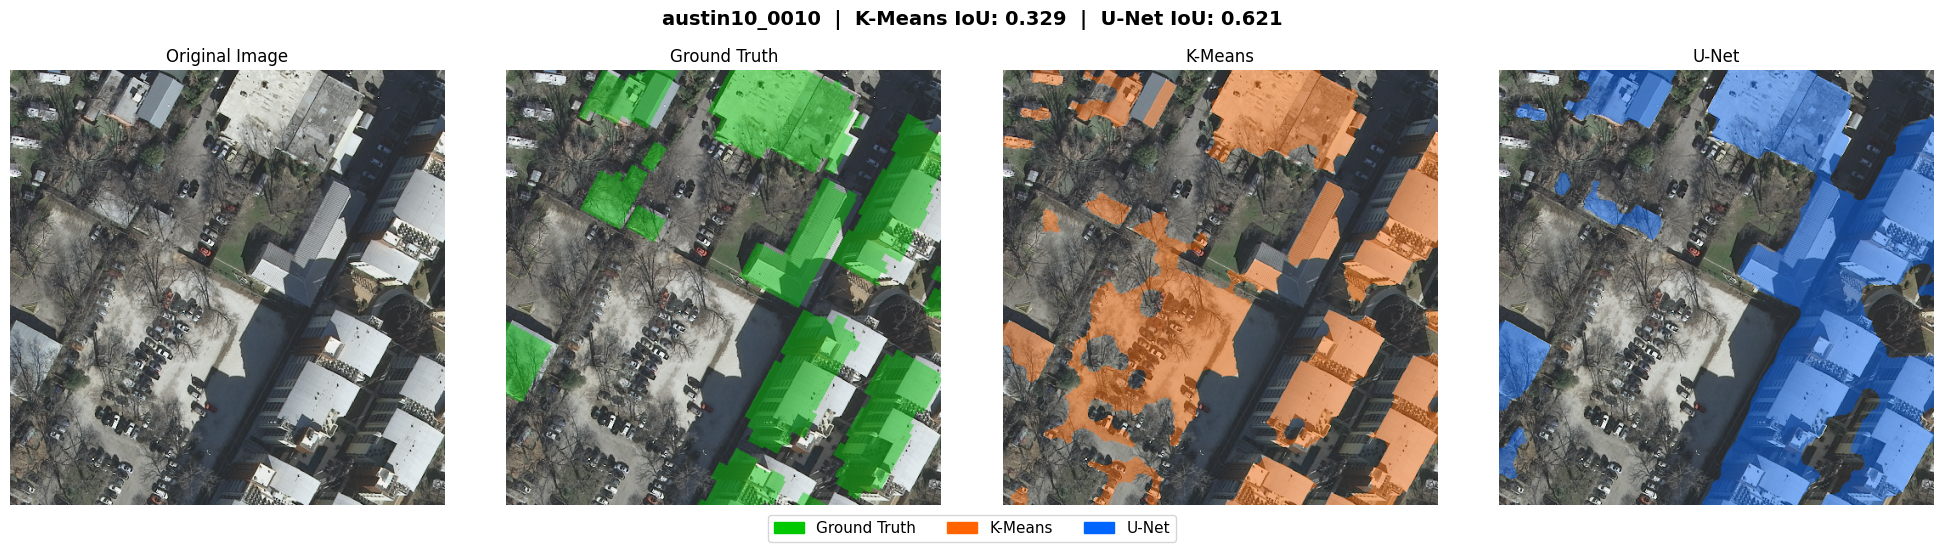

Saved: /kaggle/working/visualizations/comparison_03_austin10_0010.png


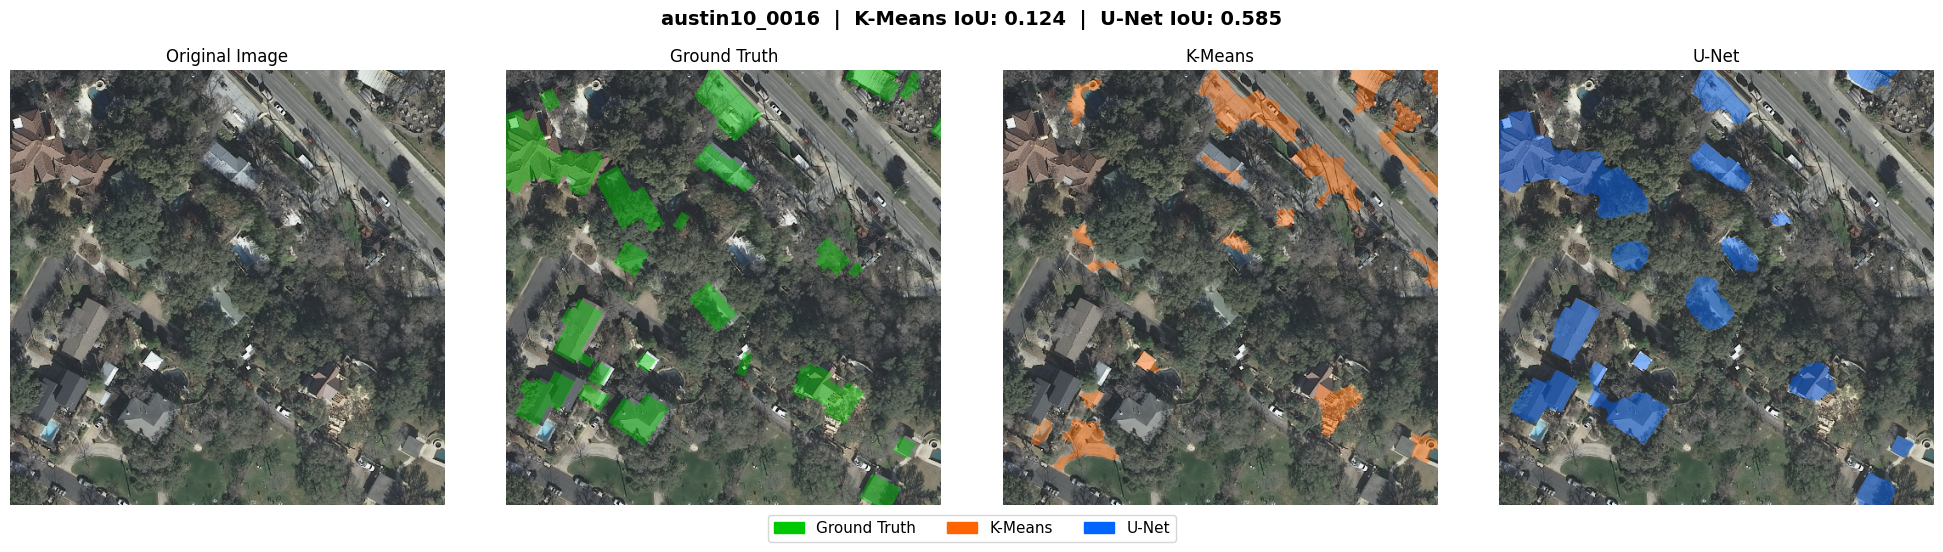

Saved: /kaggle/working/visualizations/comparison_04_austin10_0016.png


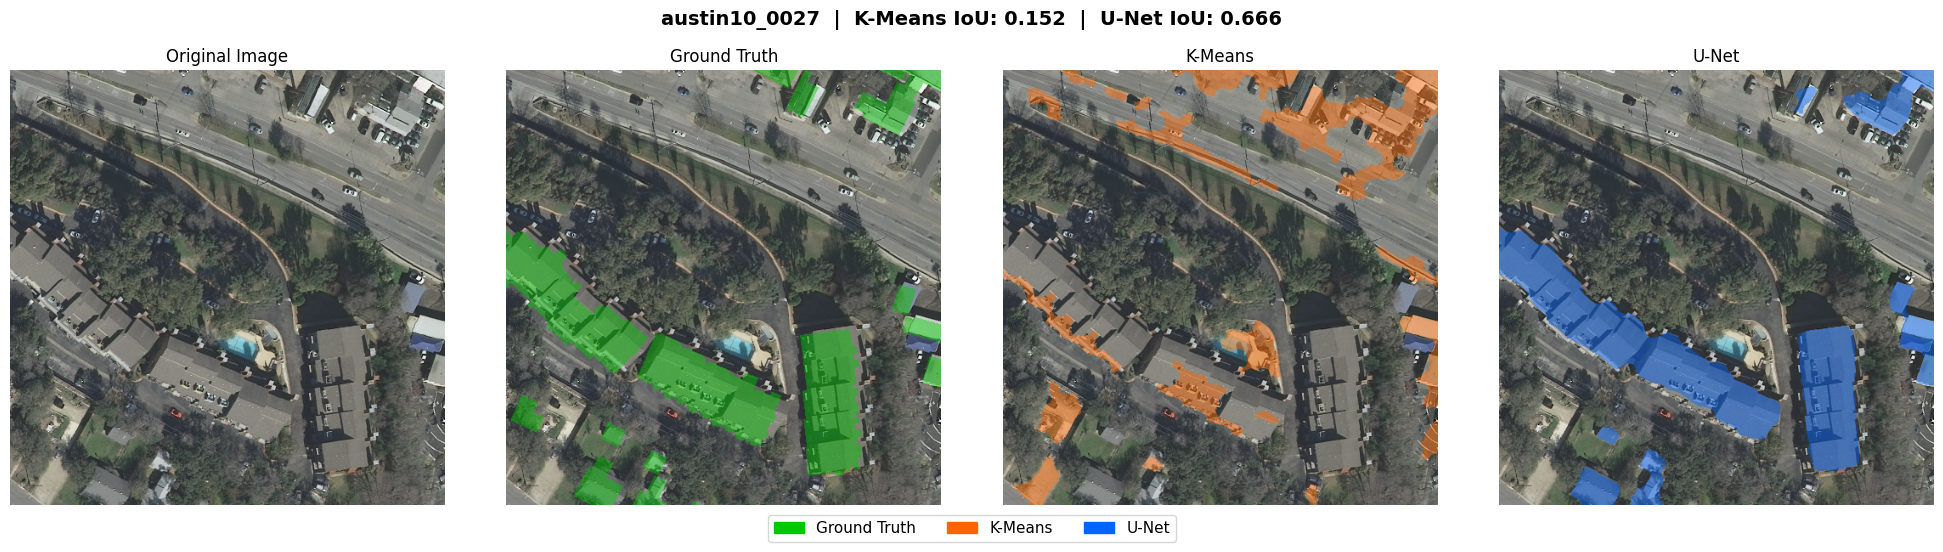

Saved: /kaggle/working/visualizations/comparison_05_austin10_0027.png


In [17]:
# ─── Generate Comparison Figures for Report ───────────────────────────────────

VIZ_SAVE_DIR = Path('/kaggle/working/visualizations')
VIZ_SAVE_DIR.mkdir(exist_ok=True)

N_SAMPLES = 5   # number of test images to visualize

if (TEST_DIR.exists() and
    KMEANS_CLEAN_DIR.exists() and
    UNET_PRED_DIR.exists()):

    test_imgs = sorted((TEST_DIR/'images').glob('*.png'))[:N_SAMPLES]

    for idx, img_path in enumerate(test_imgs):
        name = img_path.stem

        img     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        gt      = cv2.imread(str(TEST_DIR/'masks'/img_path.name), cv2.IMREAD_GRAYSCALE)
        km      = cv2.imread(str(KMEANS_CLEAN_DIR/img_path.name), cv2.IMREAD_GRAYSCALE)
        un      = cv2.imread(str(UNET_PRED_DIR/img_path.name),    cv2.IMREAD_GRAYSCALE)

        gt_bin  = (gt  > 127).astype(np.uint8)
        km_bin  = (km  > 127).astype(np.uint8)
        un_bin  = (un  > 127).astype(np.uint8)

        # Compute per-sample metrics for title
        km_iou = jaccard_score(gt_bin.ravel(), km_bin.ravel(), zero_division=0)
        un_iou = jaccard_score(gt_bin.ravel(), un_bin.ravel(), zero_division=0)

        fig = side_by_side_comparison(
            img, gt_bin, km_bin, un_bin,
            title=f'{name}  |  K-Means IoU: {km_iou:.3f}  |  U-Net IoU: {un_iou:.3f}'
        )
        save_path = VIZ_SAVE_DIR / f'comparison_{idx+1:02d}_{name}.png'
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Saved: {save_path}')
else:
    print('Required directories not found – skipping visualization (demo mode).')

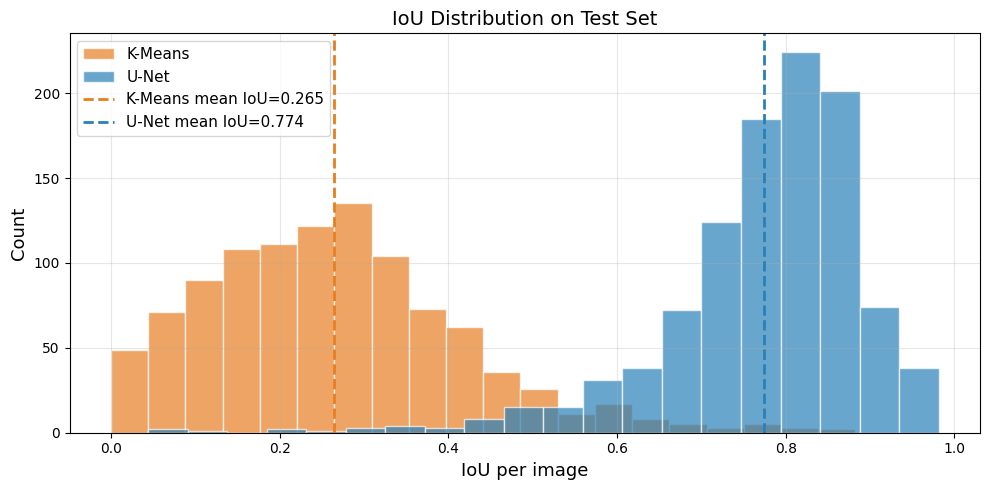

In [18]:
# ─── Per-image IoU Distribution Plot ──────────────────────────────────────────

if 'km_res' in dir() and 'un_res' in dir():
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(km_res['per_image_iou'],  bins=20, alpha=0.7,
            color='#e67e22', label='K-Means', edgecolor='white')
    ax.hist(un_res['per_image_iou'],  bins=20, alpha=0.7,
            color='#2980b9', label='U-Net',   edgecolor='white')

    ax.axvline(np.mean(km_res['per_image_iou']), color='#e67e22',
               linestyle='--', linewidth=2, label=f'K-Means mean IoU={np.mean(km_res["per_image_iou"]):.3f}')
    ax.axvline(np.mean(un_res['per_image_iou']), color='#2980b9',
               linestyle='--', linewidth=2, label=f'U-Net mean IoU={np.mean(un_res["per_image_iou"]):.3f}')

    ax.set_xlabel('IoU per image', fontsize=13)
    ax.set_ylabel('Count',         fontsize=13)
    ax.set_title('IoU Distribution on Test Set', fontsize=14)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/iou_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

Number of buildings detected : 3
Total building area          : 3787 px (1.4% of image)
Total building area          : 340.8 m²
Avg building area            : 1262.3 px


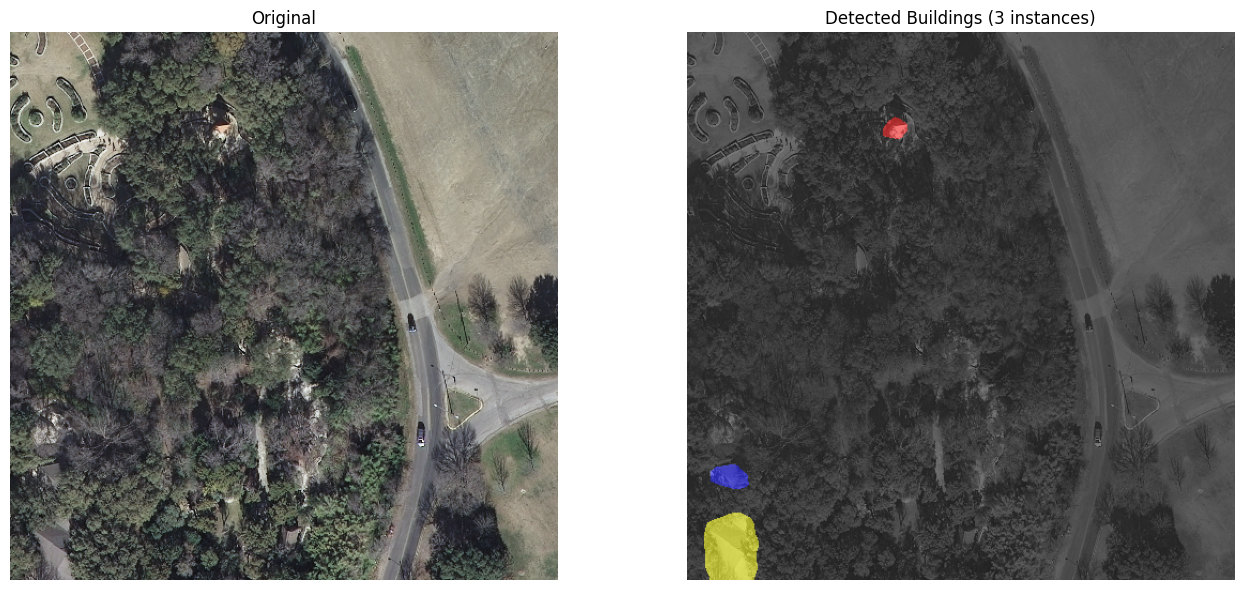

In [19]:
# ─── Connected-Region Visualization ───────────────────────────────────────────

def visualize_connected_regions(img_rgb, labeled_img):
    """
    Color-code each detected building instance in a random hue
    and display alongside original image.
    """
    from skimage.color import label2rgb
    colored = label2rgb(labeled_img, image=img_rgb, bg_label=0,
                        alpha=0.5, image_alpha=0.8)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontsize=12); axes[0].axis('off')
    axes[1].imshow(colored)
    axes[1].set_title(f'Detected Buildings ({labeled_img.max()} instances)', fontsize=12)
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/connected_regions.png', dpi=150, bbox_inches='tight')
    plt.show()


if UNET_PRED_DIR.exists() and TEST_DIR.exists():
    sample = sorted((TEST_DIR/'images').glob('*.png'))[0]
    img    = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
    pred   = cv2.imread(str(UNET_PRED_DIR / sample.name), cv2.IMREAD_GRAYSCALE)

    _, labeled_sample = analyze_buildings(pred, pixel_area_m2=0.09)
    visualize_connected_regions(img, labeled_sample)

In [20]:
# ─── Final Summary ─────────────────────────────────────────────────────────────

print('=' * 55)
print('PROJECT 16 – BUILDING FOOTPRINT EXTRACTION')
print('=' * 55)
print('\nOutput files in /kaggle/working/')
print('  patches/              – 512×512 train/val/test patches')
print('  unet_best.pth         – best U-Net checkpoint')
print('  kmeans_preds_clean/   – cleaned K-Means predictions')
print('  unet_preds_clean/     – cleaned U-Net predictions')
print('  metrics_comparison.csv– Accuracy / IoU / Dice table')
print('  training_curves.png   – loss & dice learning curves')
print('  iou_distribution.png  – per-image IoU histogram')
print('  visualizations/       – 5 side-by-side comparison panels')
print('  connected_regions.png – per-instance building coloring')
print()
if 'km_res' in dir() and 'un_res' in dir():
    print(f'  K-Means IoU  : {km_res["mean_iou"]:.4f} | Dice: {km_res["mean_dice"]:.4f}')
    print(f'  U-Net   IoU  : {un_res["mean_iou"]:.4f} | Dice: {un_res["mean_dice"]:.4f}')

PROJECT 16 – BUILDING FOOTPRINT EXTRACTION

Output files in /kaggle/working/
  patches/              – 512×512 train/val/test patches
  unet_best.pth         – best U-Net checkpoint
  kmeans_preds_clean/   – cleaned K-Means predictions
  unet_preds_clean/     – cleaned U-Net predictions
  metrics_comparison.csv– Accuracy / IoU / Dice table
  training_curves.png   – loss & dice learning curves
  iou_distribution.png  – per-image IoU histogram
  visualizations/       – 5 side-by-side comparison panels
  connected_regions.png – per-instance building coloring

  K-Means IoU  : 0.2647 | Dice: 0.3971
  U-Net   IoU  : 0.7743 | Dice: 0.8669
